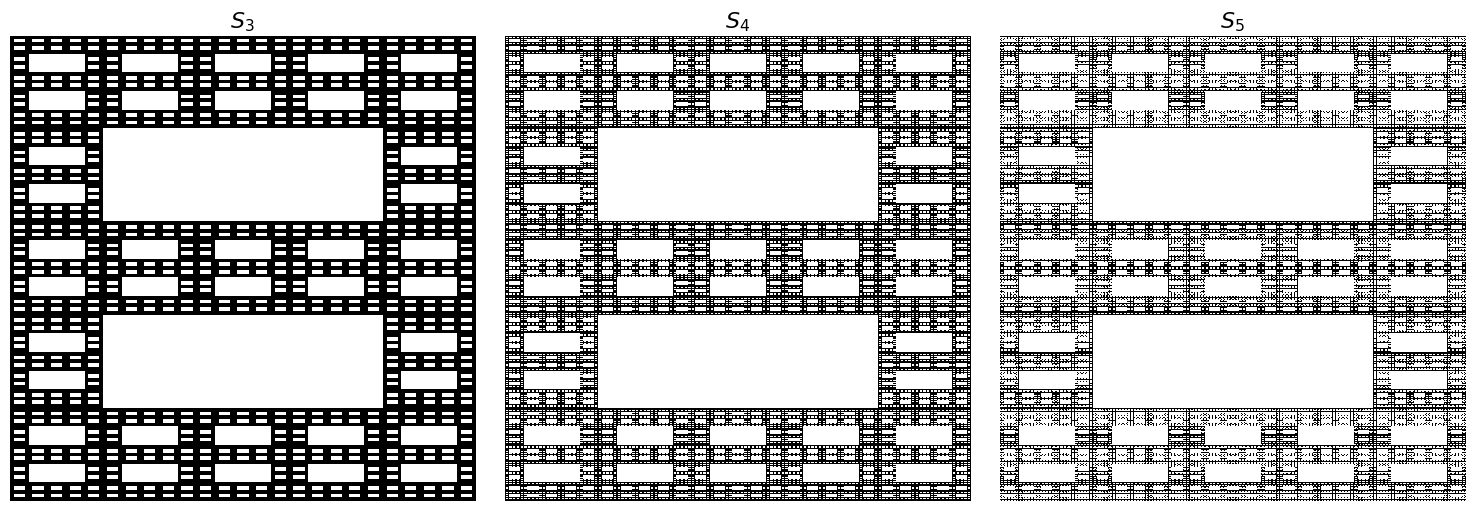

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def generate_pattern_grid(n_max):
    """Generate fractal grids up to n_max using Kronecker products."""
    # Define the 5x5 generator pattern (1 = filled, 0 = empty)
    # i in {1, 3, 5} -> indices 0, 2, 4
    # j in {1, 5}    -> indices 0, 4
    base = np.zeros((5, 5), dtype=bool)
    for i in range(5):
        for j in range(5):
            if i in {0, 2, 4} or j in {0, 4}:
                base[i, j] = True

    grids = {}
    grid = np.array([[True]], dtype=bool)
    for n in range(1, n_max + 1):
        grid = np.kron(grid, base)
        grids[n] = grid

    return grids


def plot_side_by_side(iterates=(3, 4, 5)):
    """Plot specified iterates side by side."""
    grids = generate_pattern_grid(max(iterates))

    fig, axes = plt.subplots(1, len(iterates), figsize=(5 * len(iterates), 5))

    for ax, n in zip(axes, iterates):
        ax.imshow(grids[n], cmap="binary", interpolation="nearest")
        ax.axis("off")
        ax.set_title(f"$S_{{{n}}}$", fontsize=16)

    plt.tight_layout()
    plt.show()


plot_side_by_side((3, 4, 5))